In [1]:
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model

In [2]:
gemini_llm = init_chat_model(model="gemini-2.0-flash-lite-001", model_provider="google_vertexai")
#project="glassy-keyword-461110-r8"

In [3]:
#%pip install -qU "langchain[openai]"

In [4]:
#openai_llm = init_chat_model(model="gpt-4o-mini")

In [5]:
gemini_llm.invoke("Where is apple head quarters located ?")

AIMessage(content="Apple's headquarters, known as **Apple Park**, is located in **Cupertino, California, USA**.\n", additional_kwargs={}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 7, 'candidates_token_count': 23, 'total_token_count': 30, 'prompt_tokens_details': [{'modality': 1, 'token_count': 7}], 'candidates_tokens_details': [{'modality': 1, 'token_count': 23}], 'thoughts_token_count': 0, 'cached_content_token_count': 0, 'cache_tokens_details': []}, 'finish_reason': 'STOP', 'avg_logprobs': -0.18459023600039276, 'model_name': 'gemini-2.0-flash-lite-001'}, id='run--950219c0-556e-47f3-ae7f-ca95e1fe0874-0', usage_metadata={'input_tokens': 7, 'output_tokens': 23, 'total_tokens': 30})

In [6]:
# Tools are where we have our functionality and we want llm to call our tool
from langchain.tools import tool

@tool("addition", parse_docstring=True, return_direct=True)
def add(a: int, b: int) -> int:
    """Addition of two numbers

    Args:
      a : number
      b : number

    Returns: sum of a, b
    """
    return a + b

In [7]:
gemini_llm_with_tools = gemini_llm.bind_tools([add])

In [8]:
result = gemini_llm_with_tools.invoke("What is 2 + 2 ?")


In [9]:
result

AIMessage(content='', additional_kwargs={'function_call': {'name': 'addition', 'arguments': '{"b": 2.0, "a": 2.0}'}}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 22, 'candidates_token_count': 5, 'total_token_count': 27, 'prompt_tokens_details': [{'modality': 1, 'token_count': 22}], 'candidates_tokens_details': [{'modality': 1, 'token_count': 5}], 'thoughts_token_count': 0, 'cached_content_token_count': 0, 'cache_tokens_details': []}, 'finish_reason': 'STOP', 'avg_logprobs': -0.012763234972953796, 'model_name': 'gemini-2.0-flash-lite-001'}, id='run--bfcbb74a-56cc-40af-93d1-b0da4480c706-0', tool_calls=[{'name': 'addition', 'args': {'b': 2.0, 'a': 2.0}, 'id': 'ea5533d0-8fd7-4513-8890-dae6d3b38b1c', 'type': 'tool_call'}], usage_metadata={'input_tokens': 22, 'output_tokens': 5, 'total_tokens': 27})

In [10]:
type(result)


langchain_core.messages.ai.AIMessage

In [11]:
result = gemini_llm_with_tools.invoke("I already have 2 pens now i bought 2 more what is the total pens i have ?")


In [12]:
result

AIMessage(content='', additional_kwargs={'function_call': {'name': 'addition', 'arguments': '{"b": 2.0, "a": 2.0}'}}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 34, 'candidates_token_count': 5, 'total_token_count': 39, 'prompt_tokens_details': [{'modality': 1, 'token_count': 34}], 'candidates_tokens_details': [{'modality': 1, 'token_count': 5}], 'thoughts_token_count': 0, 'cached_content_token_count': 0, 'cache_tokens_details': []}, 'finish_reason': 'STOP', 'avg_logprobs': -0.0023159977048635484, 'model_name': 'gemini-2.0-flash-lite-001'}, id='run--23a40877-7613-4731-8af6-47a6a6214eb6-0', tool_calls=[{'name': 'addition', 'args': {'b': 2.0, 'a': 2.0}, 'id': '06841ee1-af02-4388-a890-3323b957303c', 'type': 'tool_call'}], usage_metadata={'input_tokens': 34, 'output_tokens': 5, 'total_tokens': 39})

In [13]:
result = gemini_llm_with_tools.invoke("What is capital of India?")
result

AIMessage(content='I am sorry, I cannot fulfill this request. The available tools lack the functionality to provide information about the capital of India.\n', additional_kwargs={}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 20, 'candidates_token_count': 26, 'total_token_count': 46, 'prompt_tokens_details': [{'modality': 1, 'token_count': 20}], 'candidates_tokens_details': [{'modality': 1, 'token_count': 26}], 'thoughts_token_count': 0, 'cached_content_token_count': 0, 'cache_tokens_details': []}, 'finish_reason': 'STOP', 'avg_logprobs': -0.11547845143538255, 'model_name': 'gemini-2.0-flash-lite-001'}, id='run--155e9394-8670-42e6-acca-3f21335df2fa-0', usage_metadata={'input_tokens': 20, 'output_tokens': 26, 'total_tokens': 46})

In [14]:
from langgraph.graph import MessagesState


In [15]:
@tool("addition", parse_docstring=True, return_direct=True)
def add(a: int, b: int) -> int:
    """Addition of two numbers

    Args:
      a : number
      b : number

    """
    return a + b

In [16]:
@tool("subtraction", parse_docstring=True, return_direct=True)
def sub(a: int, b: int) -> int:
    """Subtract two numbers

    Args:
      a : number
      b : number

    """
    return a - b

In [17]:
@tool("multipy", parse_docstring=True, return_direct=True)
def mul(a: int, b: int) -> int:
    """Multiplication of two numbers

    Args:
      a : number
      b : number

    """
    return a * b

In [18]:
@tool("divide", parse_docstring=True, return_direct=True)
def div(a: int, b: int) -> int:
    """division of two numbers

    Args:
      a : number
      b : number

    """
    return a // b

In [19]:
gemini_llm = init_chat_model(model="gemini-2.0-flash-lite-001", model_provider="google_vertexai")


In [20]:
from langgraph.prebuilt import ToolNode
toolnode = ToolNode([add, sub, mul, div])

In [21]:
gemini_llm_with_tools = gemini_llm.bind_tools([add, sub, mul, div])


In [22]:
def call_model(state: MessagesState) -> MessagesState:
    state['messages'] = gemini_llm_with_tools.invoke(state['messages'])
    return state

In [23]:
tool_graph_builder: StateGraph = StateGraph(MessagesState)
tool_graph_builder.add_node("llm", call_model)
tool_graph_builder.add_node("tools", toolnode)
tool_graph_builder.add_edge(START, "llm")
tool_graph_builder.add_edge("llm", "tools")
tool_graph_builder.add_edge("tools", END)

tools_graph = tool_graph_builder.compile()

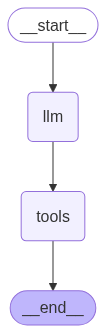

In [24]:
from IPython.display import Image, display
display(Image(tools_graph.get_graph().draw_mermaid_png()))

In [25]:
result = tools_graph.invoke({ "messages": "What is 2 * 5 ?" })
result

{'messages': [HumanMessage(content='What is 2 * 5 ?', additional_kwargs={}, response_metadata={}, id='1cf56d16-fb19-4caf-8ce2-3494b13102e2'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'multipy', 'arguments': '{"b": 5.0, "a": 2.0}'}}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 65, 'candidates_token_count': 6, 'total_token_count': 71, 'prompt_tokens_details': [{'modality': 1, 'token_count': 65}], 'candidates_tokens_details': [{'modality': 1, 'token_count': 6}], 'thoughts_token_count': 0, 'cached_content_token_count': 0, 'cache_tokens_details': []}, 'finish_reason': 'STOP', 'avg_logprobs': -0.00013878751390924057, 'model_name': 'gemini-2.0-flash-lite-001'}, id='run--21154136-a8f8-4861-bc7f-d0c8fa8d6d21-0', tool_calls=[{'name': 'multipy', 'args': {'b': 5.0, 'a': 2.0}, 'id': 'ccea7bd5-63d5-42e5-a769-d6d1c4cadb74', 'type': 'tool_call'}], usage_metadata={'input_tokens': 65, 'output_tokens': 6, 'total_tokens

In [26]:
result = tools_graph.invoke({ "messages": "I have 5 pens, now i purchase 3 more. How many pens do i have ?" })

result

{'messages': [HumanMessage(content='I have 5 pens, now i purchase 3 more. How many pens do i have ?', additional_kwargs={}, response_metadata={}, id='0a67a341-3801-4c1f-af70-d4f24256f7f8'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'addition', 'arguments': '{"b": 3.0, "a": 5.0}'}}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 77, 'candidates_token_count': 5, 'total_token_count': 82, 'prompt_tokens_details': [{'modality': 1, 'token_count': 77}], 'candidates_tokens_details': [{'modality': 1, 'token_count': 5}], 'thoughts_token_count': 0, 'cached_content_token_count': 0, 'cache_tokens_details': []}, 'finish_reason': 'STOP', 'avg_logprobs': -0.0001445974106900394, 'model_name': 'gemini-2.0-flash-lite-001'}, id='run--f4d4dc07-92e0-4625-957e-7621c39c2d6b-0', tool_calls=[{'name': 'addition', 'args': {'b': 3.0, 'a': 5.0}, 'id': 'aa84276d-a1e1-4a66-be3b-26baf6526f13', 'type': 'tool_call'}], usage_metadata={'inp

In [27]:
result = tools_graph.invoke({ "messages": "I have 5 pens, now i lost 3 . How many pens do i have ?" })
result

{'messages': [HumanMessage(content='I have 5 pens, now i lost 3 . How many pens do i have ?', additional_kwargs={}, response_metadata={}, id='5f90a4da-64fb-4265-8fc2-67fbe9f3fbe3'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'subtraction', 'arguments': '{"b": 3.0, "a": 5.0}'}}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 76, 'candidates_token_count': 6, 'total_token_count': 82, 'prompt_tokens_details': [{'modality': 1, 'token_count': 76}], 'candidates_tokens_details': [{'modality': 1, 'token_count': 6}], 'thoughts_token_count': 0, 'cached_content_token_count': 0, 'cache_tokens_details': []}, 'finish_reason': 'STOP', 'avg_logprobs': -0.08619715770085652, 'model_name': 'gemini-2.0-flash-lite-001'}, id='run--87692868-fd00-48dd-beff-9b542a920365-0', tool_calls=[{'name': 'subtraction', 'args': {'b': 3.0, 'a': 5.0}, 'id': 'a22c17c8-67ae-4254-8abb-21386930d4a1', 'type': 'tool_call'}], usage_metadata={'input_t